In [1]:
# ── Cell 1: Setup ─────────────────────────────────────────────────────────────
import sys
sys.path.insert(0, '..')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from src.models.baseline import RandomForestModel, XGBoostModel
from src.utils.hyperparameter_tuning import tune_random_forest, tune_xgboost, plot_search_results
from src.utils.metrics import print_metrics
from src.utils.mlflow_utils import setup_mlflow, mlflow_run, log_metrics

setup_mlflow()
plt.rcParams["figure.dpi"] = 120
print("✅ Setup complete")

✅ MLflow ready (SQLite backend)
✅ Setup complete


In [2]:
# ── Cell 2: Feature matrix ────────────────────────────────────────────────────
# (identical synthetic matrix — in production swap with real Kepler features)
np.random.seed(42)
n_total, n_pos = 500, 60

def make_rows(n, planet, seed_start=0):
    rows = []
    for i in range(n):
        np.random.seed(seed_start + i)
        p = np.random.uniform(5, 300)
        rows.append({
            "flux_std":                 np.random.uniform(0.003, 0.012) if planet else np.random.uniform(0.001, 0.003),
            "flux_skew":                np.random.uniform(-1.2, -0.3) if planet else np.random.uniform(-0.3, 0.3),
            "flux_kurtosis":            np.random.uniform(1.5, 5.0) if planet else np.random.uniform(-0.5, 1.5),
            "frac_below_3sigma":        np.random.uniform(0.01, 0.05) if planet else np.random.uniform(0, 0.01),
            "n_dips_detected":          np.random.uniform(5, 15) if planet else np.random.uniform(0, 3),
            "dip_mean_depth":           np.random.uniform(0.005, 0.02) if planet else np.random.uniform(0, 0.002),
            "dip_max_depth":            np.random.uniform(0.01, 0.025) if planet else np.random.uniform(0, 0.003),
            "dip_depth_consistency":    np.random.uniform(0, 0.3) if planet else np.random.uniform(0.3, 1.5),
            "folded_transit_depth":     np.random.uniform(0.005, 0.02) if planet else np.nan,
            "folded_transit_depth_ppm": np.random.uniform(5000, 20000) if planet else np.nan,
            "folded_transit_width_frac":np.random.uniform(0.01, 0.05) if planet else np.nan,
            "folded_symmetry":          np.random.uniform(0, 0.002) if planet else np.nan,
            "log_period":               np.log10(p) if planet else np.nan,
        })
    return rows

rows = make_rows(n_total-n_pos, False, 0) + make_rows(n_pos, True, 1000)
X_all = pd.DataFrame(rows)
y_all = np.array([0]*(n_total-n_pos) + [1]*n_pos)

X_train, X_val, y_train, y_val = train_test_split(
    X_all, y_all, test_size=0.2, stratify=y_all, random_state=42
)
print(f"Train: {len(X_train)} | Val: {len(X_val)}")

Train: 400 | Val: 100


In [3]:
# ── Cell 3: Baseline (before tuning) ──────────────────────────────────────────
rf_base = RandomForestModel(n_estimators=300, max_depth=15, min_samples_leaf=5)
rf_base.fit(X_train, y_train)
base_metrics = rf_base.evaluate(X_val, y_val)
print_metrics(base_metrics, "RF Baseline (before tuning)")

              precision    recall  f1-score   support

   No planet       1.00      1.00      1.00        88
      Planet       1.00      1.00      1.00        12

    accuracy                           1.00       100
   macro avg       1.00      1.00      1.00       100
weighted avg       1.00      1.00      1.00       100


────────────────────────────────────────
  RF Baseline (before tuning)
────────────────────────────────────────
  Precision        : 1.0000
  Recall           : 1.0000
  F1 Score         : 1.0000  ← primary metric
  ROC-AUC          : 1.0000
  PR-AUC           : 1.0000
────────────────────────────────────────


In [4]:

# ── Cell 4: Tune Random Forest ────────────────────────────────────────────────
print("Tuning Random Forest (40 random combos × 5-fold CV = 200 fits)...")
print("Expected time: 1-3 minutes\n")

rf_tuned_result = tune_random_forest(X_train, y_train, n_iter=40, cv=5)

print(f"\n✅ Best RF params:")
for k, v in rf_tuned_result["best_params"].items():
    print(f"   {k}: {v}")
print(f"\nBest CV F1: {rf_tuned_result['best_score']:.4f}")

Tuning Random Forest (40 random combos × 5-fold CV = 200 fits)...
Expected time: 1-3 minutes

Fitting 5 folds for each of 40 candidates, totalling 200 fits

✅ Best RF params:
   n_estimators: 500
   min_samples_leaf: 1
   max_features: 0.5
   max_depth: None
   class_weight: balanced_subsample

Best CV F1: 1.0000


In [5]:
# ── Cell 5: Evaluate tuned RF on validation set ───────────────────────────────
# Wrap the best estimator for our metric interface
from sklearn.metrics import f1_score, roc_auc_score, precision_score, recall_score, average_precision_score

best_rf_pipeline = rf_tuned_result["best_estimator"]
y_pred = best_rf_pipeline.predict(X_val)
y_prob = best_rf_pipeline.predict_proba(X_val)[:, 1]

tuned_rf_metrics = {
    "precision":         float(precision_score(y_val, y_pred, zero_division=0)),
    "recall":            float(recall_score(y_val, y_pred, zero_division=0)),
    "f1":                float(f1_score(y_val, y_pred, zero_division=0)),
    "roc_auc":           float(roc_auc_score(y_val, y_prob)),
    "average_precision": float(average_precision_score(y_val, y_prob)),
}

print(f"\nBaseline RF F1:  {base_metrics['f1']:.4f}")
print(f"Tuned    RF F1:  {tuned_rf_metrics['f1']:.4f}")
improvement = tuned_rf_metrics['f1'] - base_metrics['f1']
print(f"Improvement:     {improvement:+.4f} ({improvement/max(base_metrics['f1'],1e-6)*100:+.1f}%)")


Baseline RF F1:  1.0000
Tuned    RF F1:  1.0000
Improvement:     +0.0000 (+0.0%)


In [6]:
# ── Cell 6: Tune XGBoost ──────────────────────────────────────────────────────
print("\nTuning XGBoost (40 combos × 5-fold = 200 fits)...")
print("Expected time: 2-5 minutes\n")

xgb_tuned_result = tune_xgboost(X_train, y_train, n_iter=40, cv=5)

print(f"\n✅ Best XGBoost params:")
for k, v in xgb_tuned_result["best_params"].items():
    print(f"   {k}: {v}")
print(f"\nBest CV F1: {xgb_tuned_result['best_score']:.4f}")



Tuning XGBoost (40 combos × 5-fold = 200 fits)...
Expected time: 2-5 minutes

Fitting 5 folds for each of 40 candidates, totalling 200 fits

✅ Best XGBoost params:
   subsample: 0.6
   reg_lambda: 5.0
   reg_alpha: 0.01
   n_estimators: 200
   min_child_weight: 3
   max_depth: 5
   learning_rate: 0.05
   colsample_bytree: 0.5

Best CV F1: 1.0000


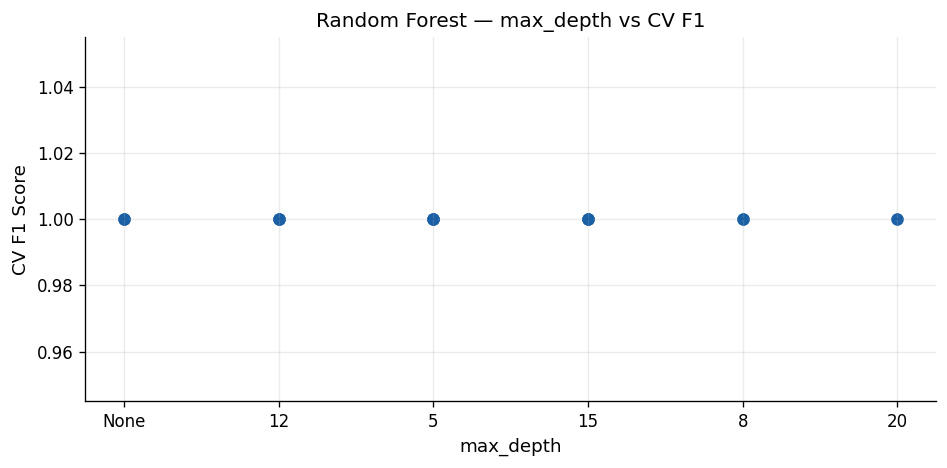

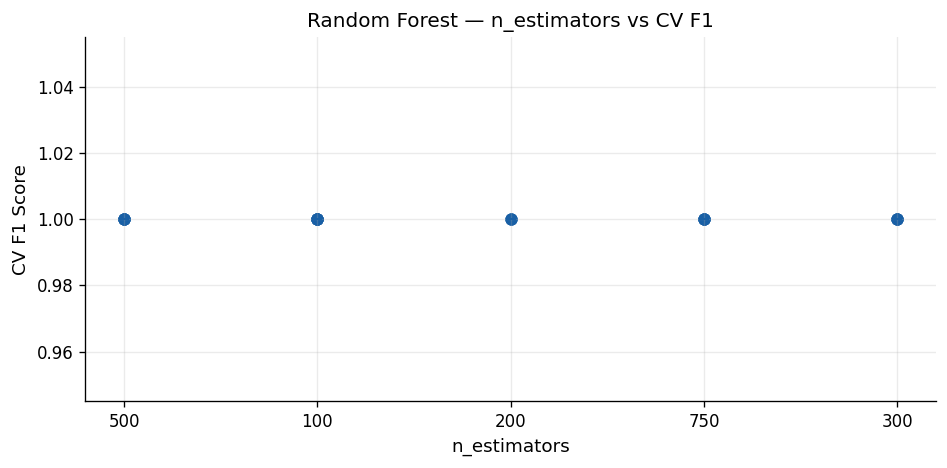

In [7]:
# ── Cell 7: Hyperparameter sensitivity plots ──────────────────────────────────
rf_cv_results = rf_tuned_result["cv_results"]

fig = plot_search_results(rf_cv_results, "max_depth", "Random Forest")
plt.show()

fig = plot_search_results(rf_cv_results, "n_estimators", "Random Forest")
plt.show()

# These plots answer: "is the model sensitive to this hyperparameter?"
# Flat plot = not sensitive (use any value)
# U-shaped = sweet spot (use the peak value)


In [8]:
# ── Cell 8: Log best params to MLflow + final summary ─────────────────────────
with mlflow_run("rf_tuned", params=rf_tuned_result["best_params"]) as run:
    log_metrics(tuned_rf_metrics)

with mlflow_run("xgb_tuned", params=xgb_tuned_result["best_params"]) as run:
    best_xgb = xgb_tuned_result["best_estimator"]
    y_pred_xgb = best_xgb.predict(X_val)
    y_prob_xgb = best_xgb.predict_proba(X_val)[:, 1]
    xgb_tuned_metrics = {
        "f1":                float(f1_score(y_val, y_pred_xgb, zero_division=0)),
        "roc_auc":           float(roc_auc_score(y_val, y_prob_xgb)),
        "average_precision": float(average_precision_score(y_val, y_prob_xgb)),
    }
    log_metrics(xgb_tuned_metrics)

print("\n" + "="*55)
print("  WEEK 2 FINAL RESULTS — TUNED MODELS")
print("="*55)
print(f"{'Model':<25} {'F1':>8} {'AUC':>8} {'PR-AUC':>8}")
print("-"*55)
print(f"{'RF (baseline)  ':<25} {base_metrics['f1']:>8.4f} {base_metrics['roc_auc']:>8.4f} {base_metrics['average_precision']:>8.4f}")
print(f"{'RF (tuned)     ':<25} {tuned_rf_metrics['f1']:>8.4f} {tuned_rf_metrics['roc_auc']:>8.4f} {tuned_rf_metrics['average_precision']:>8.4f}")
print(f"{'XGBoost (tuned)':<25} {xgb_tuned_metrics['f1']:>8.4f} {xgb_tuned_metrics['roc_auc']:>8.4f}")
print("="*55)
print("\n📋 Copy these into RESULTS.md, then Week 3 starts — CNN time! 🧠")


  WEEK 2 FINAL RESULTS — TUNED MODELS
Model                           F1      AUC   PR-AUC
-------------------------------------------------------
RF (baseline)               1.0000   1.0000   1.0000
RF (tuned)                  1.0000   1.0000   1.0000
XGBoost (tuned)             1.0000   1.0000

📋 Copy these into RESULTS.md, then Week 3 starts — CNN time! 🧠
